In [1]:
import os
import torch
from components.broadcast_components.WZ_models.wz_quant_RNN import PL_EncoderDecoder_RNN
import optuna
import numpy as np
import matplotlib.pyplot as plt
from components.broadcast_components.WZ_models.wz_quant_ANN import WZQuantizer
from scipy.stats import gaussian_kde
from components.broadcast_components.WZ_models.wz_quant_ANN import get_real_bin_prob

torch.set_float32_matmul_precision('medium')

# --------------------------------
import logging
logging.getLogger("pytorch_lightning").setLevel(logging.WARNING)
import warnings
warnings.filterwarnings("ignore", message="Starting from v1.9.0, `tensorboardX` has been removed")
warnings.filterwarnings("ignore", message="You defined a `validation_step` but have no `val_dataloader`")
warnings.filterwarnings("ignore", message="Consider setting `persistent_workers=True` in 'train_dataloader'")
warnings.filterwarnings("ignore", message="The 'val_dataloader' does not have")
warnings.filterwarnings("ignore", message="The `srun` command is available on ")

# --------------------------------

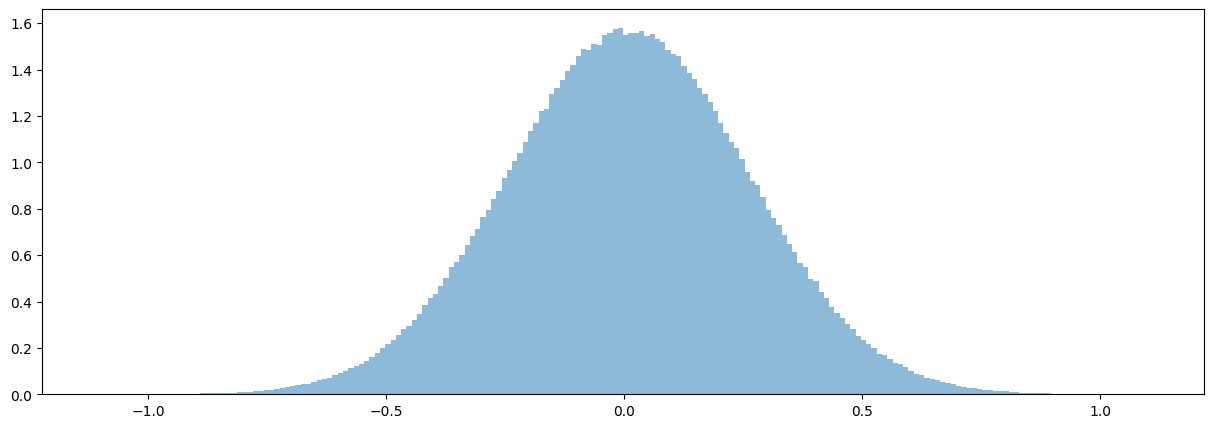

In [2]:
y = np.random.normal(0,1, 1_000_000,).astype(np.float32)
# y = np.random.random(1_000_000,).astype(np.float32)
side_info_data = y*0

side_info_data = []#[side_info_data]

temp=np.percentile(y, [0.0005, 99.9995])
temp=((y>=temp[0]) * (y<=temp[1]))
y = y[temp]
side_info_data = [a[temp] for a in side_info_data]

temp=np.percentile(y, [0.003, 99.997]).astype(np.float32)
y = (y - temp[0]) / (temp[1] - temp[0]) *2 -1
y=y.astype(np.float32)

y_argsort = np.argsort(y)

plt.figure(figsize=(15, 5))
plt.hist(y, 200, density=True, alpha=0.5)
# plt.hist(side_info_data[0], 200, density=True, alpha=0.5)
# plt.ylim(0,5)
plt.show()

In [ ]:
def objective(trial):
    sample_count=3

    # Suggest hyperparameters
    # trial.suggest_float('??????', ?, ?, log=True)
    a={
        'lr': trial.suggest_float('lr', 1e-4, 1e-3, log=True),
        'tau': trial.suggest_float('tau', 0.1, 10, log=True),
        'reconst_ld': trial.suggest_float('reconst_ld', 2, 5, log=True)
    }
    b={
        'train_sample_size': 200_000
    }
    c={
        'batch_size': 10_000
    }

    # Train your RNN WZ_models
    def test():
        wz_model = PL_EncoderDecoder_RNN(inp_dim=1, side_info_size=0, num_planes=3, bins_per_plane=4, **a).to(torch.float32)
        wz_quantizer = WZQuantizer(wz_model, count_side_info_data=0, enable_progress_bar=False, **b)

        wz_quantizer.train_model(y, side_info_data, epoch=20, device=[trial.number%2], **c)

        # Evaluate
        y_val = y[wz_quantizer.val_indices]
        bins = wz_quantizer.encoding_process(y_val)
        y_pred = wz_quantizer.decoding_process(bins, side_info_data, len(y_val))
        error = np.sum(np.abs(y_val - y_pred)) / np.sum(np.abs(y_val)) * 100

        # real bit rate
        bin_count = wz_quantizer.bin_count
        unify_bins = wz_model.unify_bins(bins)
        practical_p_u, bin_prob = get_real_bin_prob(unify_bins, bin_count)
        effective_bit_rate = torch.mean(-torch.log2(practical_p_u + 1e-12)).item()

        return error, effective_bit_rate

    error, effective_bit_rate = np.array([test() for _ in range(sample_count)]).T
    median_idx = np.argsort(error)[1]
    error, effective_bit_rate = error[median_idx], effective_bit_rate[median_idx]

    trial.set_user_attr("efctv_bit_rate", effective_bit_rate)

    return error


# Run optimization
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=200, n_jobs=8)

print(f"Best params: {study.best_params}")
print(f"Best error: {study.best_value:.2f}%")

# Previous results (commented for reference):
"""
tau: 3, 7 => 5
ld: 3.2, 4 => 3.5
lr: 1e-4, 1e3 => 8e-4
"""
print()

In [4]:
res = study.trials_dataframe(attrs=('number', 'value', 'params', 'user_attrs'))

key_list = list(res.keys())
print(key_list)

# write results to file
if not os.path.exists('meow_results'):
    os.makedirs('meow_results')
res.to_csv('meow_results/wz_quant_rnn_res.csv', index=False)


['number', 'value', 'params_lr', 'params_reconst_ld', 'params_tau', 'user_attrs_efctv_bit_rate']


In [15]:
def plot(results, first_name='tau', second_name='lr', t_name='efctv_bit_rate'):
    target_names = ['MAPE% (db)', t_name]
    x_axis = results[f'params_{first_name}']
    y_axis = results[f'params_{second_name}']
    temp = np.log10(results['value']) * 10
    z_axis = [temp, results[f'user_attrs_{target_names[1]}']]

    x_lim = [(a.min()-0.1,a.max()+0.1) for a in (x_axis, y_axis)]
    # x_lim[0] = (10, 10)
    # x_lim[1] = (0, 5)

    # Create 2D heat maps
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    for i, z in enumerate(z_axis):
        ax = axes[i]
        im = ax.hexbin(x_axis, y_axis, C=z, gridsize=30, cmap='viridis', mincnt=1)
        ax.set_xlabel(first_name)
        ax.set_ylabel(second_name)
        ax.set_title(f'Optimization Results Heat Map for {target_names[i]}')
        fig.colorbar(im, ax=ax, label=target_names[i])

    plt.tight_layout()
    plt.show()

    # Create individual parameter plots
    param_names = [first_name, second_name]
    param_data = [x_axis, y_axis]

    for param_idx, (param_name, param_values) in enumerate(zip(param_names, param_data)):
        for i, z in enumerate(z_axis):
            plt.figure(figsize=(15, 4))

            # Sort by parameter values for better visualization
            sorted_indices = np.argsort(param_values)
            sorted_x = param_values.iloc[sorted_indices]
            sorted_y = z.iloc[sorted_indices]

            # Calculate and plot the kernel density estimate
            xy = np.vstack([sorted_x, sorted_y])
            kde = gaussian_kde(xy[:, ~np.isnan(xy).any(axis=0)])
            x_grid = np.linspace(sorted_x.min(), sorted_x.max(), 100)
            y_grid = np.linspace(sorted_y.min(), sorted_y.max(), 100)
            X, Y = np.meshgrid(x_grid, y_grid)
            Z = np.reshape(kde(np.vstack([X.ravel(), Y.ravel()])).T, X.shape)
            plt.contourf(X, Y, Z, cmap='Blues', alpha=0.5)

            # Scatter plot of the data points
            plt.scatter(sorted_x, sorted_y, label=param_name, marker='o', alpha=0.6, s=15)

            # Calculate and plot the mean line with std deviation
            bins = np.linspace(sorted_x.min(), sorted_x.max(), 15)
            digitized = np.digitize(sorted_x, bins)
            bin_means = [sorted_y[digitized == j].mean() for j in range(1, len(bins))]
            bin_stds = [sorted_y[digitized == j].std() for j in range(1, len(bins))]
            bin_centers = (bins[:-1] + bins[1:]) / 2

            bin_means = np.array(bin_means)
            bin_stds = np.array(bin_stds)

            plt.plot(bin_centers, bin_means, color='red', linewidth=2, label='Mean Trend')
            plt.fill_between(bin_centers, bin_means - bin_stds, bin_means + bin_stds,
                             color='red', alpha=0.2, label='Std Dev')

            plt.xlabel(param_name)
            plt.ylabel(target_names[i])
            plt.title(f'{param_name} vs {target_names[i]}')
            plt.grid(True, alpha=0.3)
            plt.xlim(x_lim[param_idx])
            plt.legend()
            plt.show()

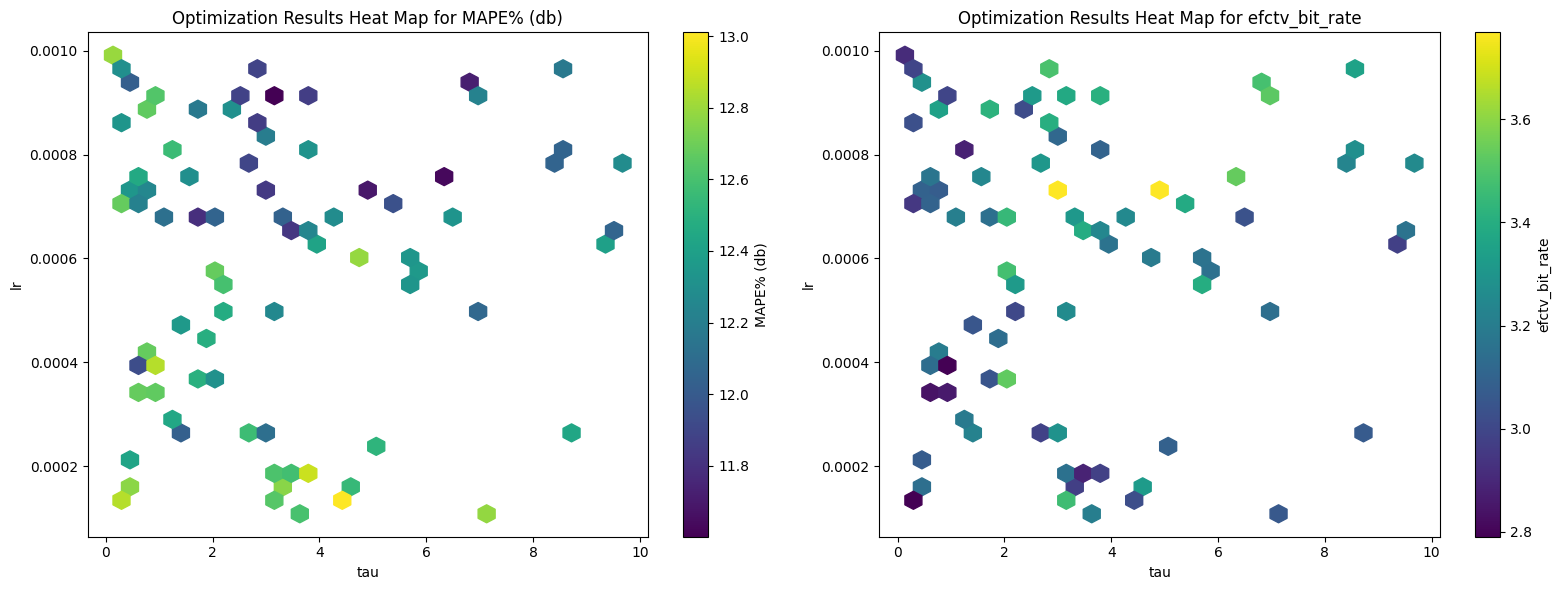

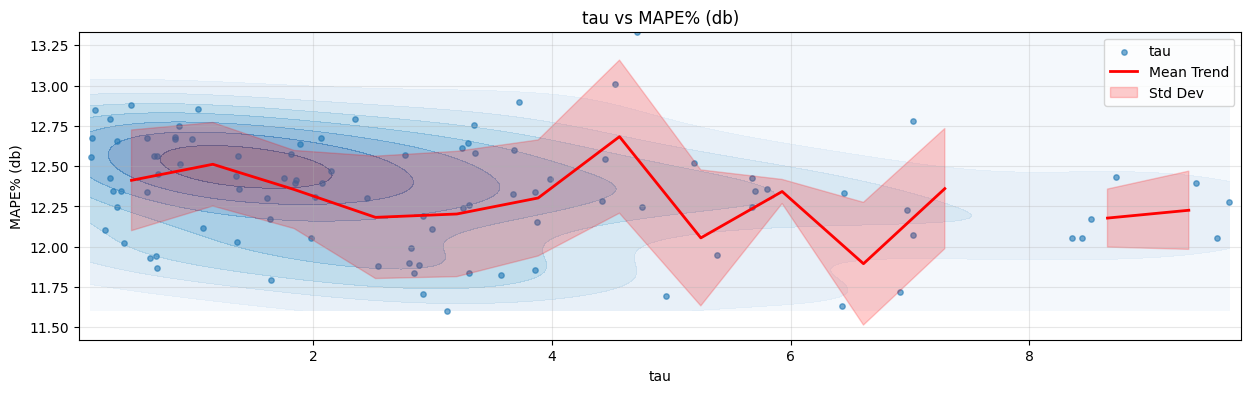

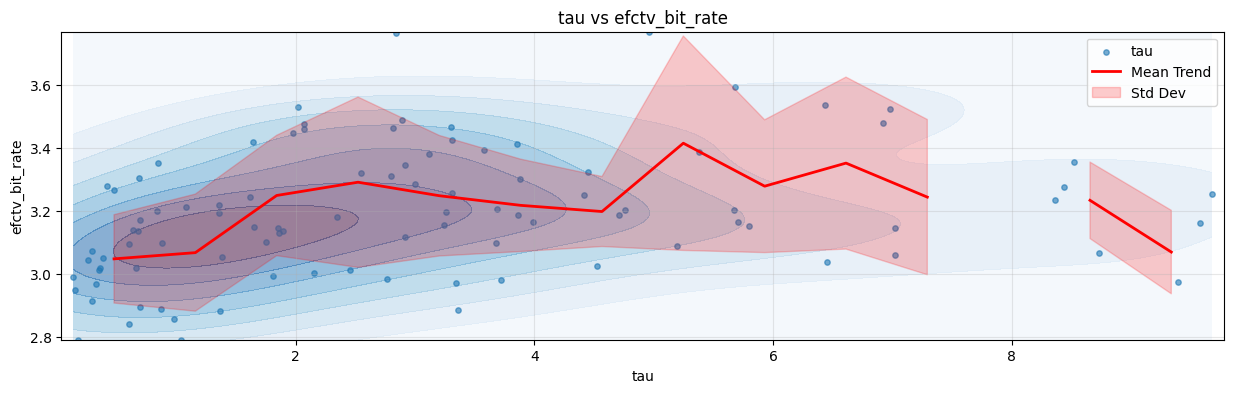

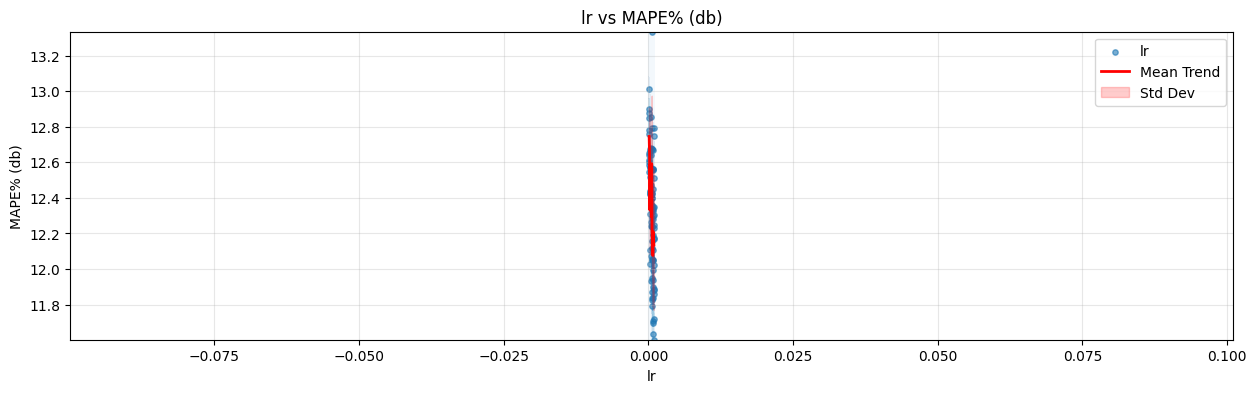

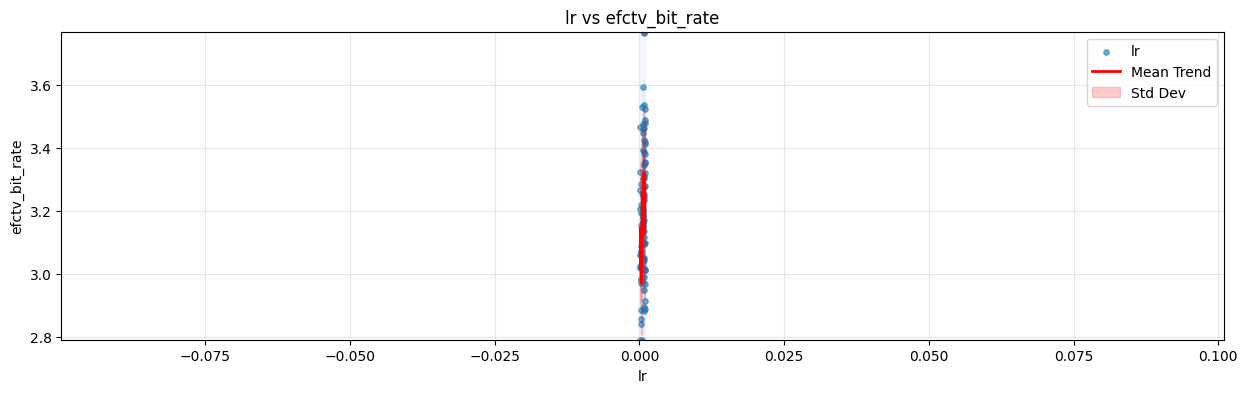

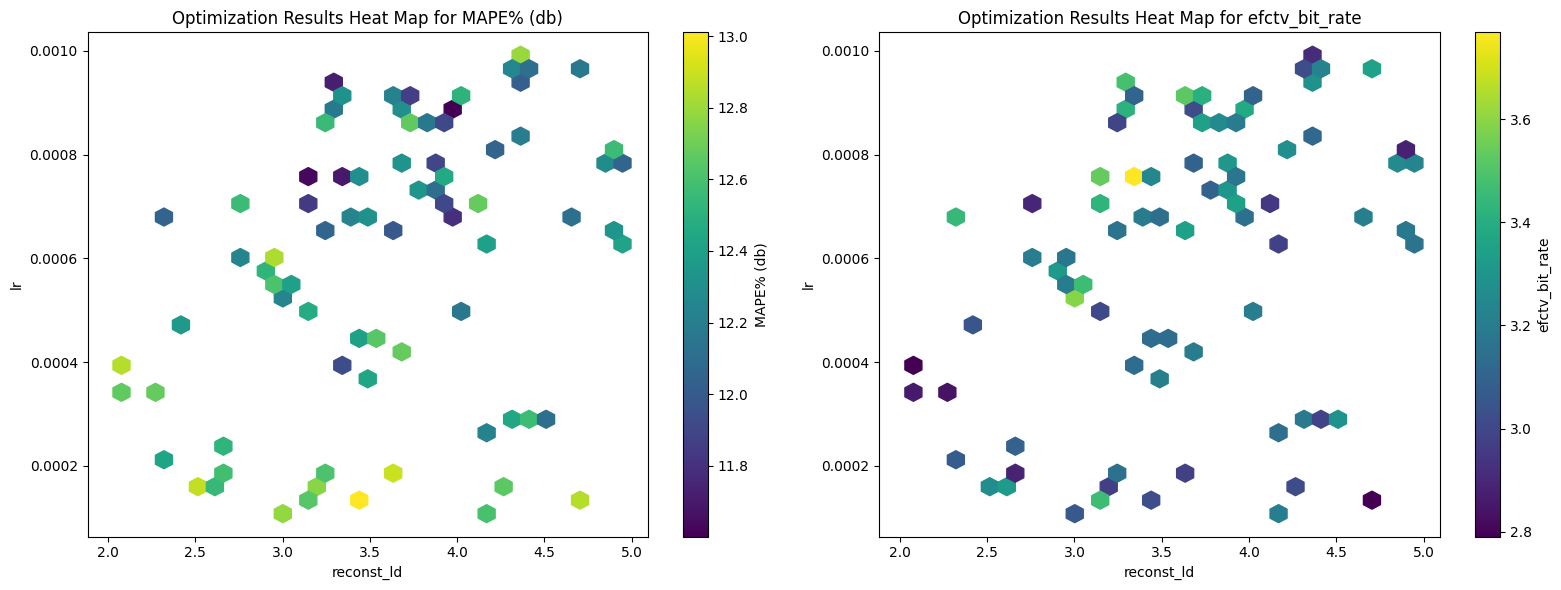

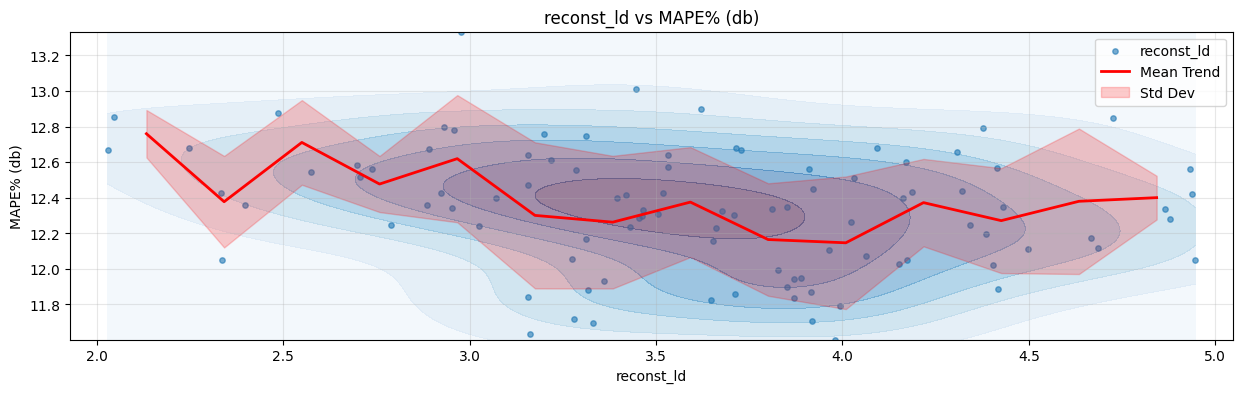

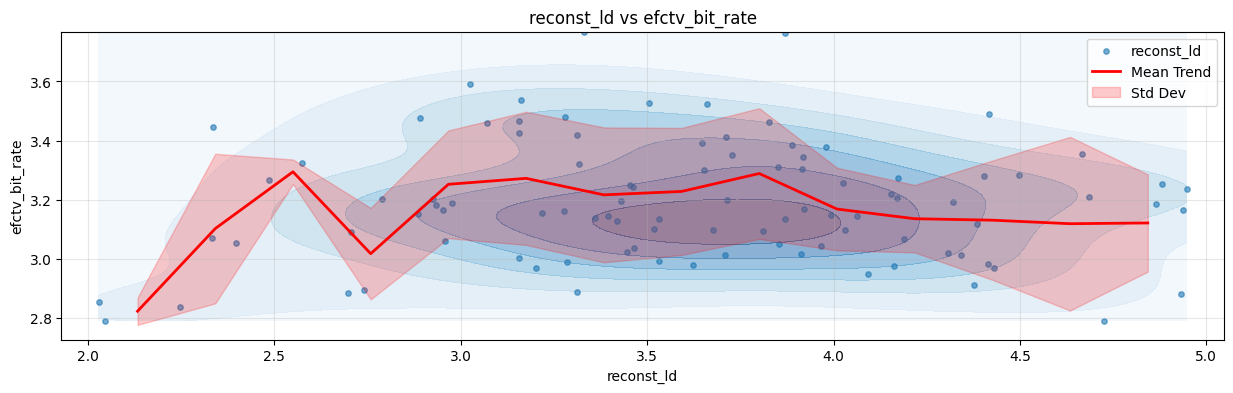

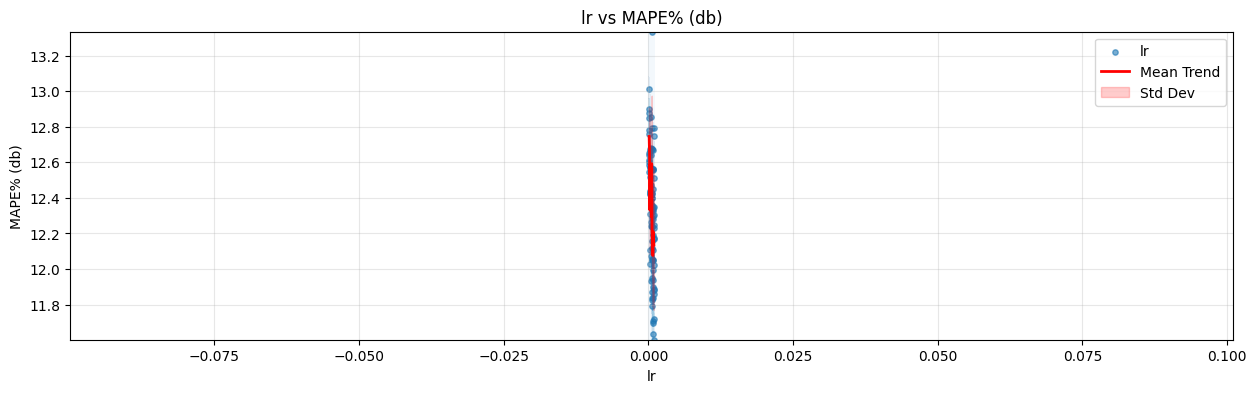

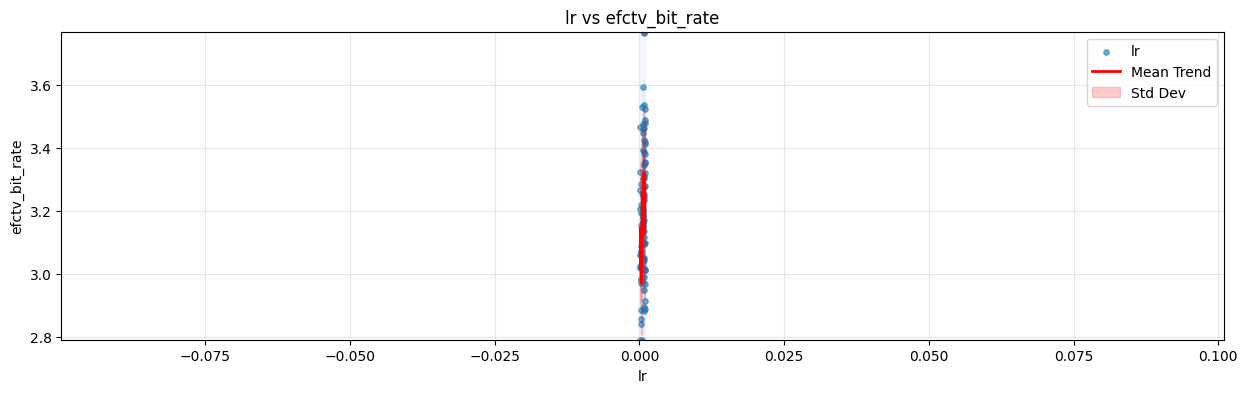

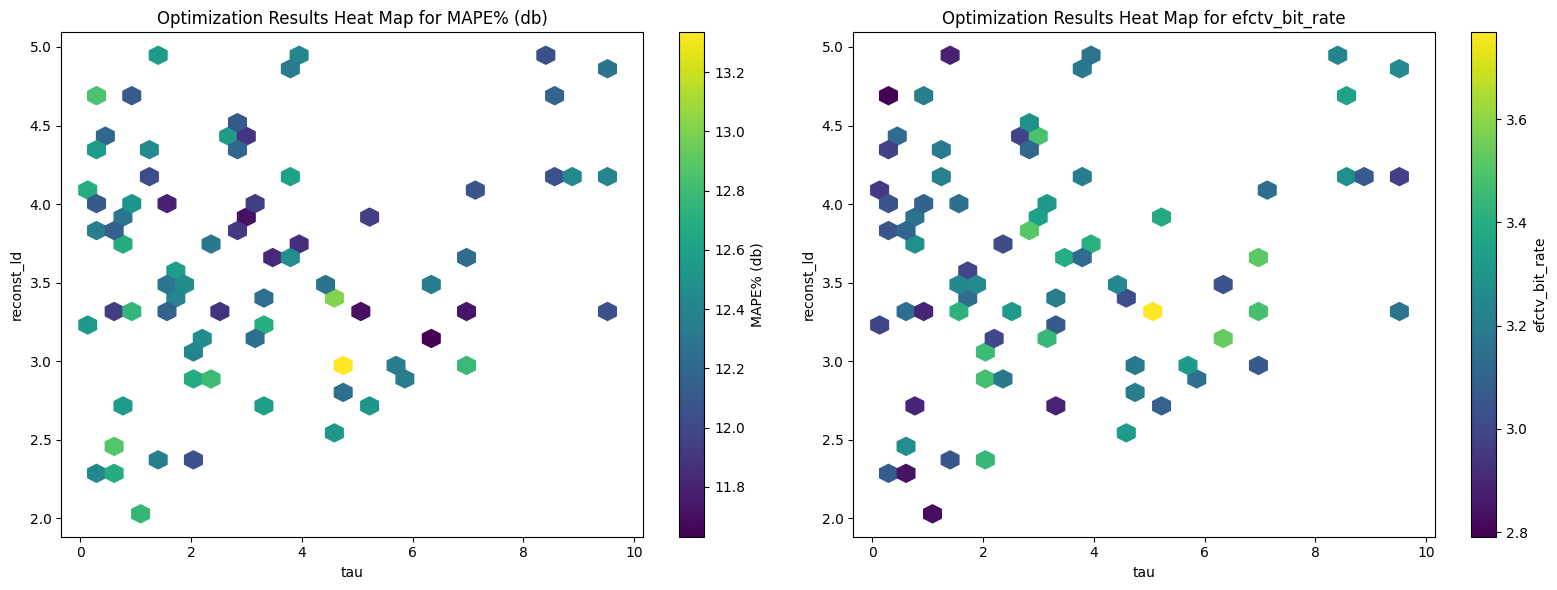

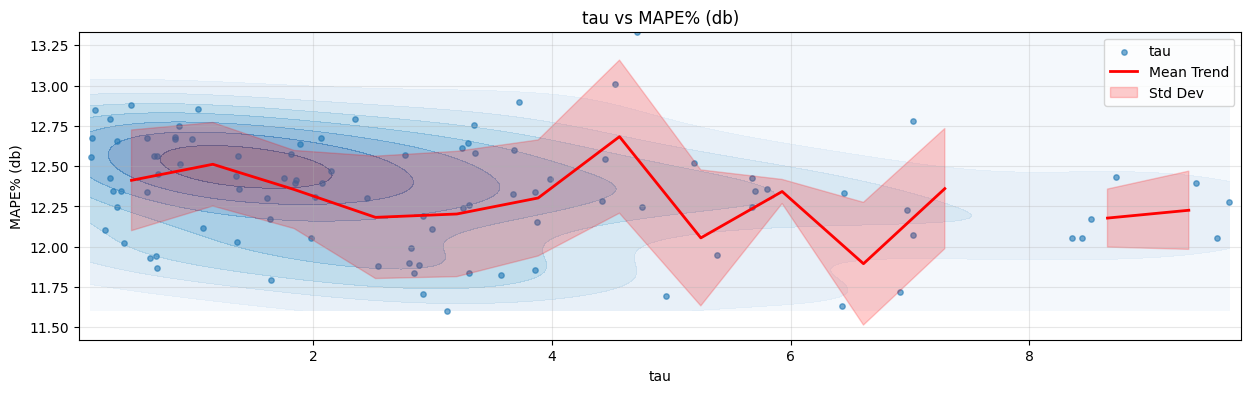

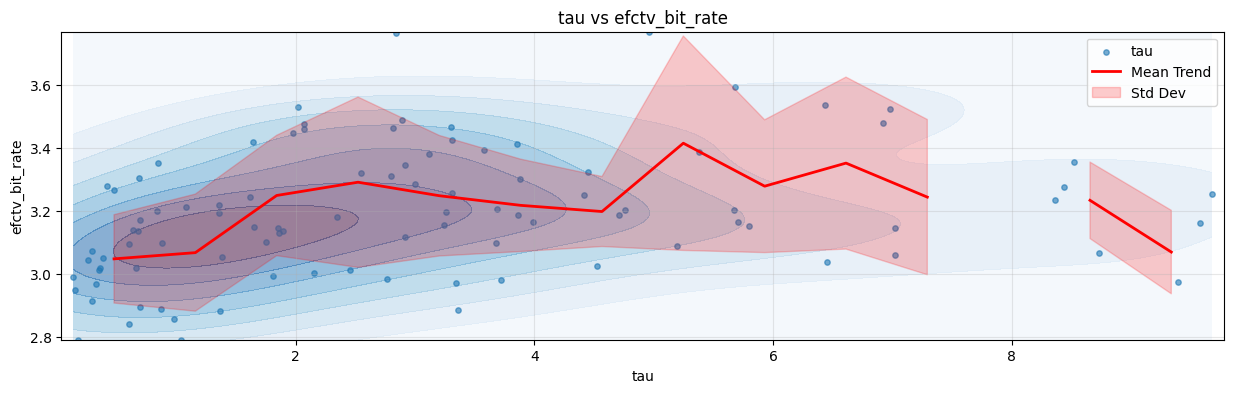

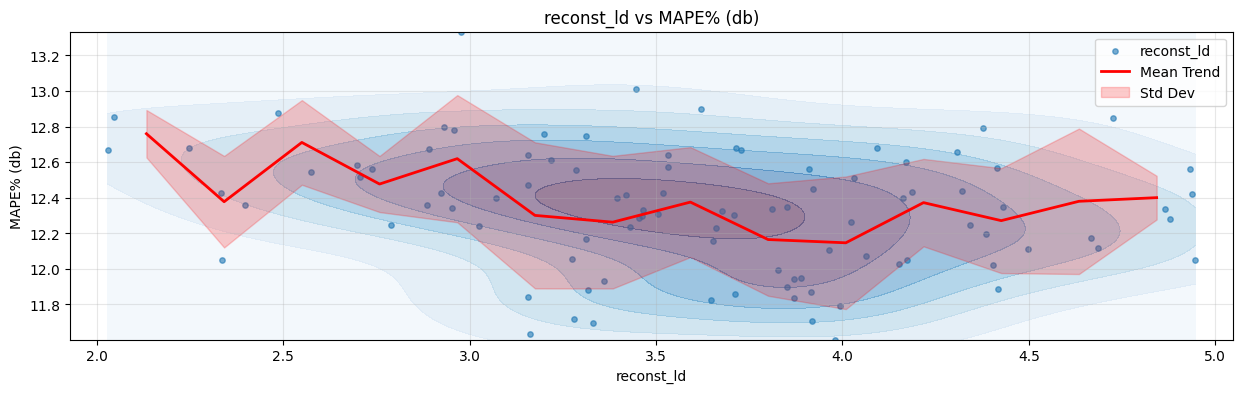

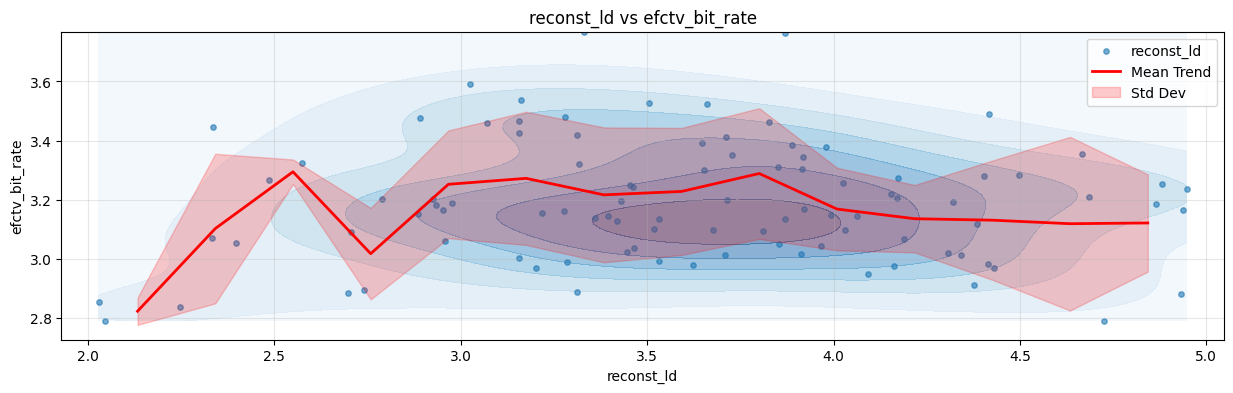

In [16]:
plot(res, first_name='tau', second_name='lr', t_name='efctv_bit_rate')
plot(res, first_name='reconst_ld', second_name='lr', t_name='efctv_bit_rate')
plot(res, first_name='tau', second_name='reconst_ld', t_name='efctv_bit_rate')

.


.


.


.

.
